# Correctivity — Single Movement Binary Classifier Training

Trains a binary LSTM classifier on data produced by `CreateDataSetSingleMovement.ipynb`.

| | |
|---|---|
| Input shape | `(30 frames, 63 features)` — hand landmarks only |
| Output | Single sigmoid unit — probability that the movement is occurring |
| Loss | Binary cross-entropy |
| Metrics | Accuracy, Precision, Recall, F1, ROC-AUC |
| Export | `.h5` + TF.js conversion command |

### Why binary, not N-class?
Each Correctivity model answers one question: *"Is this movement happening right now?"*  
Binary framing gives cleaner precision/recall trade-off control via the confidence threshold,
and avoids the need to enumerate all possible 'other' movements.

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall

2026-03-08 01:10:19.444452: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-08 01:10:19.467755: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-08 01:10:19.467781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-08 01:10:19.468589: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-08 01:10:19.472799: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-08 01:10:19.473560: I tensorflow/core/platform/cpu_feature_guard.cc:1

## Configuration

Must match the values used in `CreateDataSetSingleMovement.ipynb`.

In [2]:
MOVEMENT_ID    = 'finger_extension_right'
NO_SEQUENCES   = 30        # must match collection setting
SEQUENCE_LENGTH = 30
FEATURES        = 63       # 21 landmarks × 3 (x, y, z)

DATA_PATH = os.path.join('..', 'datasets', 'correctivity', MOVEMENT_ID)

# Training hyper-parameters
EPOCHS       = 500
BATCH_SIZE   = 32
L2_NORM      = 0.001
DROPOUT_RATE = 0.3
TEST_SIZE    = 0.15

# Confidence threshold used at inference time (tune after reviewing ROC curve)
CONFIDENCE_THRESHOLD = 0.7

MODEL_SAVE_PATH = os.path.join('..', 'models', f'{MOVEMENT_ID}.h5')
LOG_DIR = os.path.join('Logs', f'{MOVEMENT_ID}')

print(f'Movement : {MOVEMENT_ID}')
print(f'Data path: {DATA_PATH}')
print(f'Model out: {MODEL_SAVE_PATH}')

Movement : finger_extension_right
Data path: ../datasets/correctivity/finger_extension_right
Model out: ../models/finger_extension_right.h5


## Load Dataset

In [3]:
sequences, labels = [], []

for label, cls in enumerate(['target', 'other']):
    cls_path = os.path.join(DATA_PATH, cls)
    seq_dirs = sorted(os.listdir(cls_path), key=lambda x: int(x))
    for seq_dir in seq_dirs:
        window = []
        for frame_num in range(SEQUENCE_LENGTH):
            frame = np.load(os.path.join(cls_path, seq_dir, f'{frame_num}.npy'))
            window.append(frame)
        sequences.append(window)
        labels.append(label)  # 1 = target, 0 = other  (see label order above)

X = np.array(sequences, dtype=np.float32)   # (N, 30, 63)
y = np.array(labels, dtype=np.float32)       # (N,)  binary

print(f'X shape : {X.shape}   (expected (N, {SEQUENCE_LENGTH}, {FEATURES}))')
print(f'y shape : {y.shape}')
print(f'Class balance — target: {y.sum():.0f}  other: {(1-y).sum():.0f}')

X shape : (60, 30, 63)   (expected (N, 30, 63))
y shape : (60,)
Class balance — target: 30  other: 30


## Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]} samples   Test: {X_test.shape[0]} samples')

Train: 51 samples   Test: 9 samples


## Build Model

In [5]:
model = Sequential([
    LSTM(64, return_sequences=True, activation='tanh',
         input_shape=(SEQUENCE_LENGTH, FEATURES), kernel_regularizer=l2(L2_NORM)),
    LSTM(128, return_sequences=True, activation='tanh',
         kernel_regularizer=l2(L2_NORM)),
    Dropout(DROPOUT_RATE),
    LSTM(64, return_sequences=False, activation='tanh',
         kernel_regularizer=l2(L2_NORM)),
    BatchNormalization(),
    Dense(64, activation='relu', kernel_regularizer=l2(L2_NORM)),
    Dense(32, activation='relu', kernel_regularizer=l2(L2_NORM)),
    # Single sigmoid unit — outputs P(movement == target)
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
    ]
)

model.summary()

2026-03-08 01:10:21.046323: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-08 01:10:21.050985: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 64)            32768     
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           98816     
                                                                 
 dropout (Dropout)           (None, 30, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 batch_normalization (Batch  (None, 64)                256       
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                        

## Train

In [6]:
os.makedirs(LOG_DIR, exist_ok=True)

callbacks = [
    TensorBoard(log_dir=LOG_DIR),
    # Stop early if val_loss doesn't improve for 50 epochs
    EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1),
    # Halve LR when val_loss plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=20, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks,
)

Epoch 1/500
2/2 [==============================] - 3s 602ms/step - loss: 1.2763 - accuracy: 0.4651 - precision: 0.3333 - recall: 0.0455 - val_loss: 1.1825 - val_accuracy: 0.5000 - val_precision: 0.5000 - val_recall: 1.0000 - lr: 0.0010
Epoch 2/500
2/2 [==============================] - 0s 38ms/step - loss: 1.1299 - accuracy: 0.6512 - precision: 0.8182 - recall: 0.4091 - val_loss: 1.1780 - val_accuracy: 0.5000 - val_precision: 0.5000 - val_recall: 1.0000 - lr: 0.0010
Epoch 3/500
2/2 [==============================] - 0s 38ms/step - loss: 1.1263 - accuracy: 0.6047 - precision: 0.6923 - recall: 0.4091 - val_loss: 1.1730 - val_accuracy: 0.5000 - val_precision: 0.5000 - val_recall: 1.0000 - lr: 0.0010
Epoch 4/500
2/2 [==============================] - 0s 38ms/step - loss: 1.1107 - accuracy: 0.6512 - precision: 0.8182 - recall: 0.4091 - val_loss: 1.1671 - val_accuracy: 0.5000 - val_precision: 0.5000 - val_recall: 1.0000 - lr: 0.0010
Epoch 5/500
2/2 [==============================] - 0s 37ms/

## Training Curves

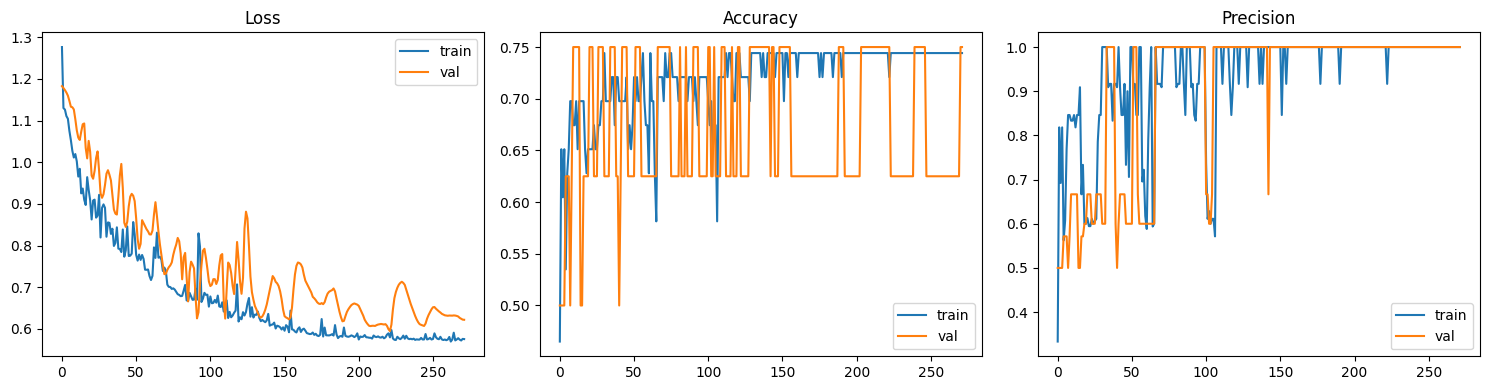

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'accuracy', 'precision'],
    ['Loss', 'Accuracy', 'Precision'],
):
    ax.plot(history.history[metric], label='train')
    val_key = f'val_{metric}'
    if val_key in history.history:
        ax.plot(history.history[val_key], label='val')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## Save Model

In [8]:
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
model.save(MODEL_SAVE_PATH)
print(f'Model saved to {MODEL_SAVE_PATH}')

Model saved to ../models/finger_extension_right.h5


/home/masaakim/miniconda3/envs/gpu_env/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluate on Test Set

In [9]:
y_prob = model.predict(X_test).flatten()           # sigmoid probabilities
y_pred = (y_prob >= CONFIDENCE_THRESHOLD).astype(int)

print(f'Confidence threshold : {CONFIDENCE_THRESHOLD}')
print()
print(classification_report(y_test.astype(int), y_pred, target_names=['other', 'target']))

1/1 [==============================] - 0s 478ms/step
Confidence threshold : 0.7

              precision    recall  f1-score   support

       other       0.50      0.60      0.55         5
      target       0.33      0.25      0.29         4

    accuracy                           0.44         9
   macro avg       0.42      0.42      0.42         9
weighted avg       0.43      0.44      0.43         9



## Confusion Matrix

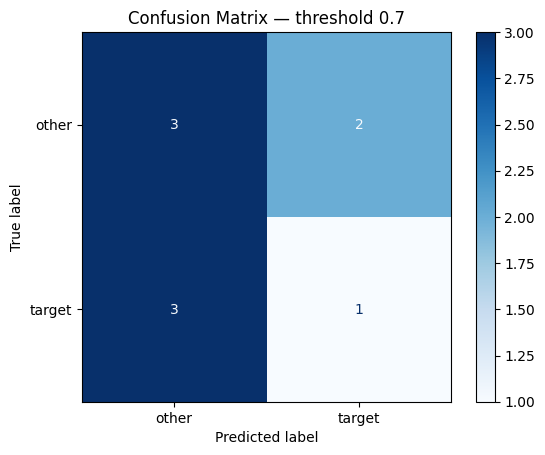

True Positives  (movement detected correctly) : 1
False Positives (false alarm)                 : 2
False Negatives (missed movement)             : 3
True Negatives  (rest correctly ignored)      : 3


In [10]:
cm = confusion_matrix(y_test.astype(int), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['other', 'target'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — threshold {CONFIDENCE_THRESHOLD}')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (movement detected correctly) : {tp}')
print(f'False Positives (false alarm)                 : {fp}')
print(f'False Negatives (missed movement)             : {fn}')
print(f'True Negatives  (rest correctly ignored)      : {tn}')

## ROC Curve

Use this to choose the `CONFIDENCE_THRESHOLD` in `src/data/movements.ts`.  
Higher threshold → fewer false positives (good for rep counting accuracy).  
Lower threshold → fewer missed reps.

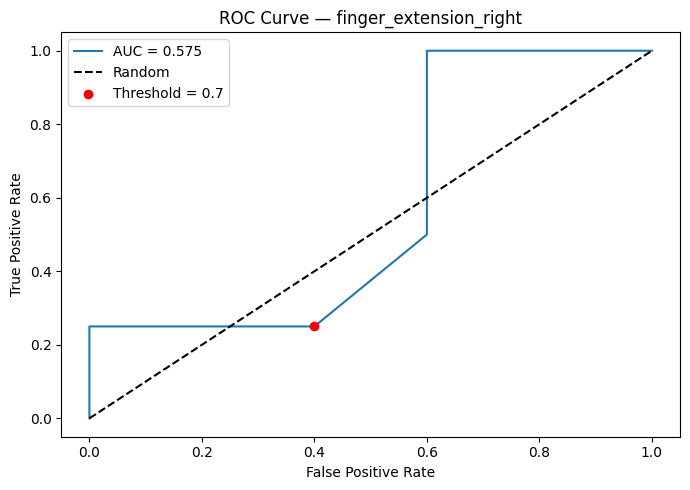

AUC: 0.5750  (target: > 0.95 before using model in production)


In [11]:
fpr, tpr, thresholds = roc_curve(y_test.astype(int), y_prob)
auc = roc_auc_score(y_test.astype(int), y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Mark the chosen threshold
idx = np.argmin(np.abs(thresholds - CONFIDENCE_THRESHOLD))
plt.scatter(fpr[idx], tpr[idx], color='red', zorder=5,
            label=f'Threshold = {CONFIDENCE_THRESHOLD}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {MOVEMENT_ID}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC: {auc:.4f}  (target: > 0.95 before using model in production)')
if auc < 0.95:
    print('WARNING: AUC below 0.95 — collect more data or tune hyper-parameters before deploying.')

## Convert to TF.js

Run the cell below to export the model for the React app.  
Requires: `pip install tensorflowjs`

The output is written to `correctivity-app/public/models/<MOVEMENT_ID>/`.

In [12]:
tfjs_output = os.path.join(
    '..', 'correctivity-app', 'public', 'models', MOVEMENT_ID
)

convert_cmd = (
    f'tensorflowjs_converter '
    f'--input_format=keras '
    f'"{os.path.abspath(MODEL_SAVE_PATH)}" '
    f'"{os.path.abspath(tfjs_output)}"'
)

print('Running:', convert_cmd)
ret = os.system(convert_cmd)

if ret == 0:
    files = os.listdir(tfjs_output)
    print(f'\nTF.js model written to: {tfjs_output}')
    print('Files:', files)
    total_mb = sum(
        os.path.getsize(os.path.join(tfjs_output, f))
        for f in files
    ) / 1e6
    print(f'Total size: {total_mb:.2f} MB')
else:
    print('Conversion failed. Make sure tensorflowjs is installed: pip install tensorflowjs')

Running: tensorflowjs_converter --input_format=keras "/home/masaakim/Documents/GitHub/HandSignDetecton/models/finger_extension_right.h5" "/home/masaakim/Documents/GitHub/HandSignDetecton/correctivity-app/public/models/finger_extension_right"
Conversion failed. Make sure tensorflowjs is installed: pip install tensorflowjs


sh: line 1: tensorflowjs_converter: command not found


## Next Steps

1. Check the ROC curve — adjust `CONFIDENCE_THRESHOLD` if needed, then update `repStateMachineConfig.confidenceThreshold` in `correctivity-app/src/data/movements.ts`
2. Confirm `public/models/<MOVEMENT_ID>/model.json` exists in the React app
3. Start the React app (`npm run dev`) and verify the debug overlay shows confidence > 0.7 for the target movement
4. Run the M0 exit-criteria test: 10 reps → confidence consistently > 0.7; still hand → confidence < 0.5